# MCS-201 Hardware Acceleration
**Artificial Intelligence and System Engineering · Prince of Songkla University, Phuket Campus**

---

# Lab 0 — Environment Setup and Your First Measurement
### การติดตั้งสภาพแวดล้อมและการวัดสมรรถนะครั้งแรก

| | |
|---|---|
| **สัปดาห์** | 1 |
| **วันปฏิบัติการ** | จันทร์ 17 ส.ค. 2569 |
| **กำหนดส่ง** | จันทร์ 17 ส.ค. 2569 **ภายใน 13.00 น.** (วันเดียวกับคาบปฏิบัติการ) |
| **น้ำหนัก** | อยู่ในหมวด Lab ซึ่งคิดเป็น 15% ของคะแนนรายวิชา (ทุกแลปถ่วงน้ำหนักเท่ากัน) |
| **ช่องทางส่ง** | LMS — lms.psu.ac.th |
| **ไฟล์ที่ต้องส่ง** | `Lab0_<รหัสนักศึกษา>.ipynb` (ไฟล์เดียว) |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ · thitinan.kl@phuket.psu.ac.th · ห้อง 6714 |


> **การส่งงาน** อัปโหลดผ่าน LMS ภายใน 13.00 น. ของวันปฏิบัติการ
>
> **การส่งช้า** นับจาก 13.00 น. ของวันปฏิบัติการ หักวันละ 10% ของคะแนนแลปนี้
> และไม่รับหลังพ้นกำหนด 7 วัน (ยกเว้นกรณีมีเหตุจำเป็นและได้รับอนุมัติล่วงหน้า)
>
> **ห้ามล้าง output ก่อนส่ง** ผู้ตรวจต้องเห็นผลลัพธ์ที่รันจริง

> **ก่อนเริ่ม** ตั้งค่า Runtime เป็น GPU: เมนู **Runtime → Change runtime type → T4 GPU**

## 1. วัตถุประสงค์ (Objectives)

1. ติดตั้งและตรวจสอบสภาพแวดล้อมที่มี GPU ให้พร้อมใช้งานตลอดภาคการศึกษา — *CLO1*
2. อ่านและตีความข้อมูลจาก `nvidia-smi` ได้ถูกต้อง — *CLO1*
3. วัดเวลาการทำงานของ GPU อย่างถูกวิธี โดยเข้าใจว่า CUDA call เป็น asynchronous — *CLO2, CLO3*
4. สังเกตความสัมพันธ์ระหว่างขนาดปัญหากับ speedup ที่ได้จาก GPU — *CLO1*

## 2. สิ่งที่ต้องเตรียม (Prerequisites)

- บัญชี Google สำหรับใช้ Colab หรือเครื่องที่มี NVIDIA GPU พร้อมไดรเวอร์และ CUDA Toolkit
- ความรู้ Python พื้นฐานและการใช้ Jupyter Notebook

**สูตรที่จะใช้ในคำถามข้อ Q2**

$$\text{peak FP32} = (\text{จำนวน FP32 lanes}) \times 2 \times (\text{boost clock})$$

เลข 2 มาจากคำสั่ง FMA (fused multiply-add) ที่นับเป็น 2 FLOP
ค่า peak ของการ์ดที่พบบ่อยในรายวิชานี้:

| การ์ด | FP32 lanes | boost clock | peak FP32 |
|---|---|---|---|
| Tesla T4 | 40 SM × 64 = 2,560 | 1.59 GHz | 8.1 TFLOPS |
| L4 | 58 SM × 128 = 7,424 | 2.04 GHz | 30.3 TFLOPS |
| A100 | 108 SM × 64 = 6,912 | 1.41 GHz | 19.5 TFLOPS |

---
## 3. ขั้นตอนการปฏิบัติ (Procedure)

### ส่วนที่ 1 — ตรวจสอบว่าเห็น GPU

**3.1** เปลี่ยน Runtime เป็น GPU แล้วรันสองเซลล์ถัดไป บันทึกผลลัพธ์ไว้ (อย่าล้าง output)

In [ ]:
!nvidia-smi

Mon Aug 17 04:22:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
import torch
print("PyTorch      :", torch.__version__)
print("CUDA (torch) :", torch.version.cuda)
print("CUDA พร้อมใช้ :", torch.cuda.is_available())

assert torch.cuda.is_available(), "ไม่พบ GPU — เปลี่ยน Runtime เป็น GPU ก่อน"

p = torch.cuda.get_device_properties(0)
print("Device name        :", p.name)
print("Total memory (MiB) :", p.total_memory // 1024**2)
print("Compute capability :", f"{p.major}.{p.minor}")
print("SM count           :", p.multi_processor_count)

PyTorch      : 2.11.0+cu128
CUDA (torch) : 12.8
CUDA พร้อมใช้ : True
Device name        : Tesla T4
Total memory (MiB) : 14912
Compute capability : 7.5
SM count           : 40


**3.2** กรอกค่าที่อ่านได้ลงในตารางที่ 1 (ดับเบิลคลิกที่เซลล์นี้เพื่อแก้ไข)

### ตารางที่ 1 — ข้อมูลอุปกรณ์

| รายการ | ค่าที่อ่านได้ |
|---|---|
| ชื่อ GPU | Tesla T4 |
| หน่วยความจำทั้งหมด (MiB) | 14912 |
| Driver version | 580.82.07 |
| CUDA version | 13.0 |
| Compute capability | 7.5 |
| สภาพแวดล้อมที่ใช้ (Colab / เครื่องส่วนตัว) | Colab |

---
### ส่วนที่ 2 — วัดเวลา CPU เทียบกับ GPU

**3.3** เติมโค้ดในส่วน `TODO` ให้สมบูรณ์ แล้วรันการทดลองกับ n = 512, 1024, 2048 และ 4096

> **ทำไมต้องมี warm-up**
> การเรียก GPU ครั้งแรกต้องเสียเวลาสร้าง CUDA context และโหลด kernel ซึ่งไม่ใช่เวลาคำนวณจริง
> จึงต้องรันทิ้ง 1 ครั้งก่อนเริ่มจับเวลา
>
> **ทำไมต้อง synchronize**
> คำสั่ง CUDA เป็นแบบ asynchronous คือส่งงานเข้าคิวแล้วคืนค่ากลับทันที
> ถ้าไม่เรียก `torch.cuda.synchronize()` ก่อนหยุดนาฬิกา เราจะวัดเวลาที่ Python ใช้ส่งคำสั่ง
> ไม่ใช่เวลาที่ GPU ทำงานจริง

In [ ]:
import torch, time

def bench(dev, n=4096, reps=10):
    """คืนค่า (เวลาเฉลี่ยต่อครั้งเป็นวินาที, TFLOPS)"""
    a = torch.randn(n, n, device=dev)
    b = torch.randn(n, n, device=dev)

    torch.matmul(a, b)                    # warm-up
    if dev == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(reps):
        c = torch.matmul(a, b)

    # TODO (1): เติมคำสั่งซิงโครไนซ์ตรงนี้ ถ้า dev == "cuda"
    if dev == "cuda":
        torch.cuda.synchronize()

    dt = (time.perf_counter() - t0) / reps

    # TODO (2): คำนวณ TFLOPS  (การคูณเมทริกซ์ n x n ใช้ 2 * n**3 FLOP)
    tflops = (2 * (n ** 3)) / (dt * 1e12)

    assert tflops is not None, "ยังไม่ได้ทำ TODO (2) — คำนวณ tflops ก่อน"
    return dt, tflops

In [ ]:
sizes = [512, 1024, 2048, 4096]
rows = []

for n in sizes:
    dt_cpu, tf_cpu = bench("cpu",  n, reps=3)
    dt_gpu, tf_gpu = bench("cuda", n, reps=10)
    speedup = dt_cpu / dt_gpu
    rows.append((n, dt_cpu*1e3, tf_cpu, dt_gpu*1e3, tf_gpu, speedup))
    print(f"n={n:5d}  CPU {dt_cpu*1e3:9.1f} ms ({tf_cpu:5.3f} TF)   "
          f"GPU {dt_gpu*1e3:8.2f} ms ({tf_gpu:5.2f} TF)   speedup {speedup:7.1f}x")

n=  512  CPU       2.1 ms (0.127 TF)   GPU     0.13 ms ( 1.99 TF)   speedup    15.6x
n= 1024  CPU      20.1 ms (0.107 TF)   GPU     0.83 ms ( 2.59 TF)   speedup    24.2x
n= 2048  CPU     128.9 ms (0.133 TF)   GPU     6.03 ms ( 2.85 TF)   speedup    21.4x
n= 4096  CPU    1038.2 ms (0.132 TF)   GPU    38.21 ms ( 3.60 TF)   speedup    27.2x


### ตารางที่ 2 — ผลการวัด

| n | CPU time (ms) | CPU TFLOPS | GPU time (ms) | GPU TFLOPS | Speedup (×) |
|---|---|---|---|---|---|
| 512 | 2.1 | 0.127 | 0.13 | 1.99 | 15.6 |
| 1024 | 20.1 | 0.107 | 0.83  | 2.59 | 24.2 |
| 2048 | 128.9 | 0.133 | 6.03 | 2.85 | 21.4 |
| 4096 | 1038.2 | 0.132 | 39.21 | 3.60 | 27.2 |

---
### ส่วนที่ 3 — สรุปผลด้วยกราฟ

**3.4** วาดกราฟ 1 รูป: แกน x เป็นขนาด n (สเกล log ฐาน 2) แกน y เป็น speedup
ใส่ชื่อแกนและหน่วยให้ครบ

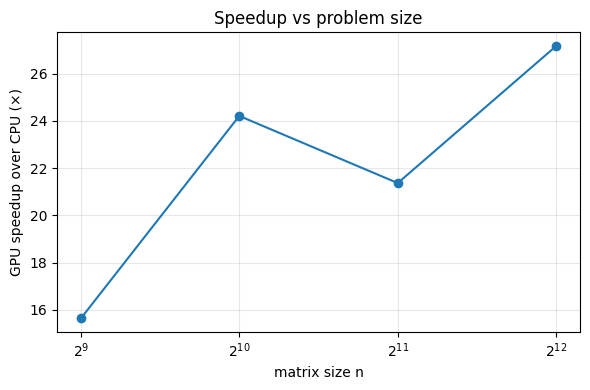

In [ ]:
import matplotlib.pyplot as plt

ns       = [r[0] for r in rows]
speedups = [r[5] for r in rows]

plt.figure(figsize=(6, 4))
plt.plot(ns, speedups, marker="o")
plt.xscale("log", base=2)
plt.xlabel("matrix size n")
plt.ylabel("GPU speedup over CPU (×)")
plt.title("Speedup vs problem size")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

---
### ส่วนที่ 4 — การทดลองเชิงสังเกต (Deliberate mistake)

**3.5** รันเซลล์ถัดไปเพื่อดูว่าจะเกิดอะไรขึ้นเมื่อวัดเวลา GPU **โดยไม่ซิงโครไนซ์**

In [ ]:
n = 4096
a = torch.randn(n, n, device="cuda")
b = torch.randn(n, n, device="cuda")
torch.matmul(a, b); torch.cuda.synchronize()      # warm-up

t0 = time.perf_counter()
for _ in range(10):
    c = torch.matmul(a, b)
dt_wrong = (time.perf_counter() - t0) / 10        # ไม่มี synchronize

torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(10):
    c = torch.matmul(a, b)
torch.cuda.synchronize()
dt_right = (time.perf_counter() - t0) / 10        # มี synchronize

print(f"ไม่ซิงโครไนซ์ : {dt_wrong*1e6:10.1f} us")
print(f"ซิงโครไนซ์    : {dt_right*1e6:10.1f} us")
print(f"ต่างกัน        : {dt_right/dt_wrong:10.1f} เท่า")

ไม่ซิงโครไนซ์ :      100.0 us
ซิงโครไนซ์    :    36516.0 us
ต่างกัน        :      365.1 เท่า


**3.6** อธิบายผลที่ได้ (3–5 ประโยค)

เมื่อเรียกใช้คำสั่ง torch.cuda.synchronize() เวลาที่บันทึกได้จะเพิ่มขึ้นเป็น 36,516.0 µs เพราะโปรแกรมบังคับให้ CPU หยุดรอจนกระทั่ง GPU ประมวลผลการคำนวณจริงเสร็จสิ้นทั้งหมด

---
## 4. คำถามวิเคราะห์ (Analysis Questions)

ตอบข้อละ 3–5 ประโยค โดยดับเบิลคลิกแก้ไขในเซลล์นี้

**Q1.** จากตารางที่ 2 ที่ขนาด n เท่าใด GPU จึงเริ่มเร็วกว่า CPU และเพราะเหตุใดที่ n เล็ก ๆ GPU จึงไม่ได้เปรียบ

_ตอบ:_ GPU เริ่มเร็วกว่า CPU ตั้งแต่ n = 512 ขึ้นไป
       และ n เล็ก ๆ GPU จึงไม่ได้เปรียบเพราะมี Kernel Launch Overhead และ Latency ในการส่งคำสั่ง ซึ่งกินเวลามากกว่าเวลาคำนวณจริง

**Q2.** ค่า TFLOPS ที่วัดได้จาก GPU คิดเป็นกี่เปอร์เซ็นต์ของ peak FP32 ตามสเปก และส่วนต่างหายไปกับอะไร

_ตอบ:_ 44.4% ของ Peak Performance ส่วนต่างของประสิทธิภาพที่หายไปส่วนใหญ่เกิดจากปัญหาคอขวดของ Memory Bandwidth และ Memory Latency ในการดึงข้อมูลจาก Global Memory เข้าสู่ Registers

**Q3.** ถ้าเปลี่ยนจาก float32 เป็น float16 ท่านคาดว่าเวลาจะเปลี่ยนไปในทิศทางใด เพราะเหตุใด

_ตอบ:_ เวลาจะลดลงอย่างมาก เพราะ float16 ใช้ขนาดบิตลดลงครึ่งหนึ่ง ช่วยลดภาระ Memory Bandwidth ทำให้ส่งถ่ายข้อมูลได้เร็วขึ้นเป็น 2 เท่า

---
## 5. รายการสิ่งที่ต้องส่ง (Submission Checklist)

- [ ] โน้ตบุ๊กชื่อ `Lab0_<รหัสนักศึกษา>.ipynb` รันครบทุกเซลล์และ**ไม่ล้าง output**
- [ ] ผลลัพธ์ `nvidia-smi` และตารางที่ 1 กรอกครบ
- [ ] ตารางที่ 2 ครบทั้ง 4 ขนาด
- [ ] กราฟ speedup เทียบกับ n พร้อมชื่อแกน
- [ ] คำอธิบายผลการทดลองส่วนที่ 4
- [ ] คำตอบคำถามวิเคราะห์ Q1–Q3

## 6. เกณฑ์การให้คะแนน (Marking Rubric)

| องค์ประกอบ | คะแนน | เกณฑ์การพิจารณา |
|---|---|---|
| ความครบถ้วนของข้อมูลอุปกรณ์ | 15 | ตารางที่ 1 ครบทุกช่องและตรงกับ output ของตนเอง |
| ความถูกต้องของการวัด | 30 | มี warm-up และ synchronize ถูกตำแหน่ง คำนวณ TFLOPS ถูก ครบ 4 ขนาด |
| กราฟและการนำเสนอ | 15 | กราฟมีชื่อแกน หน่วย และอ่านเข้าใจได้ |
| การทดลองส่วนที่ 4 | 10 | แสดงค่าที่วัดได้เมื่อไม่ซิงโครไนซ์ พร้อมคำอธิบายที่ถูกต้อง |
| คำตอบคำถามวิเคราะห์ | 30 | Q1–Q3 ข้อละ 10 ให้เหตุผลเชิงสถาปัตยกรรม ไม่ใช่แค่บรรยายตัวเลข |
| **รวม** | **100** | |

> **หมายเหตุเรื่องคะแนน** ตาราง 100 คะแนนด้านบนเป็นคะแนนภายในของแลปนี้
> ก่อนแปลงเป็นสัดส่วนในหมวด Lab (15% ของคะแนนรายวิชา)